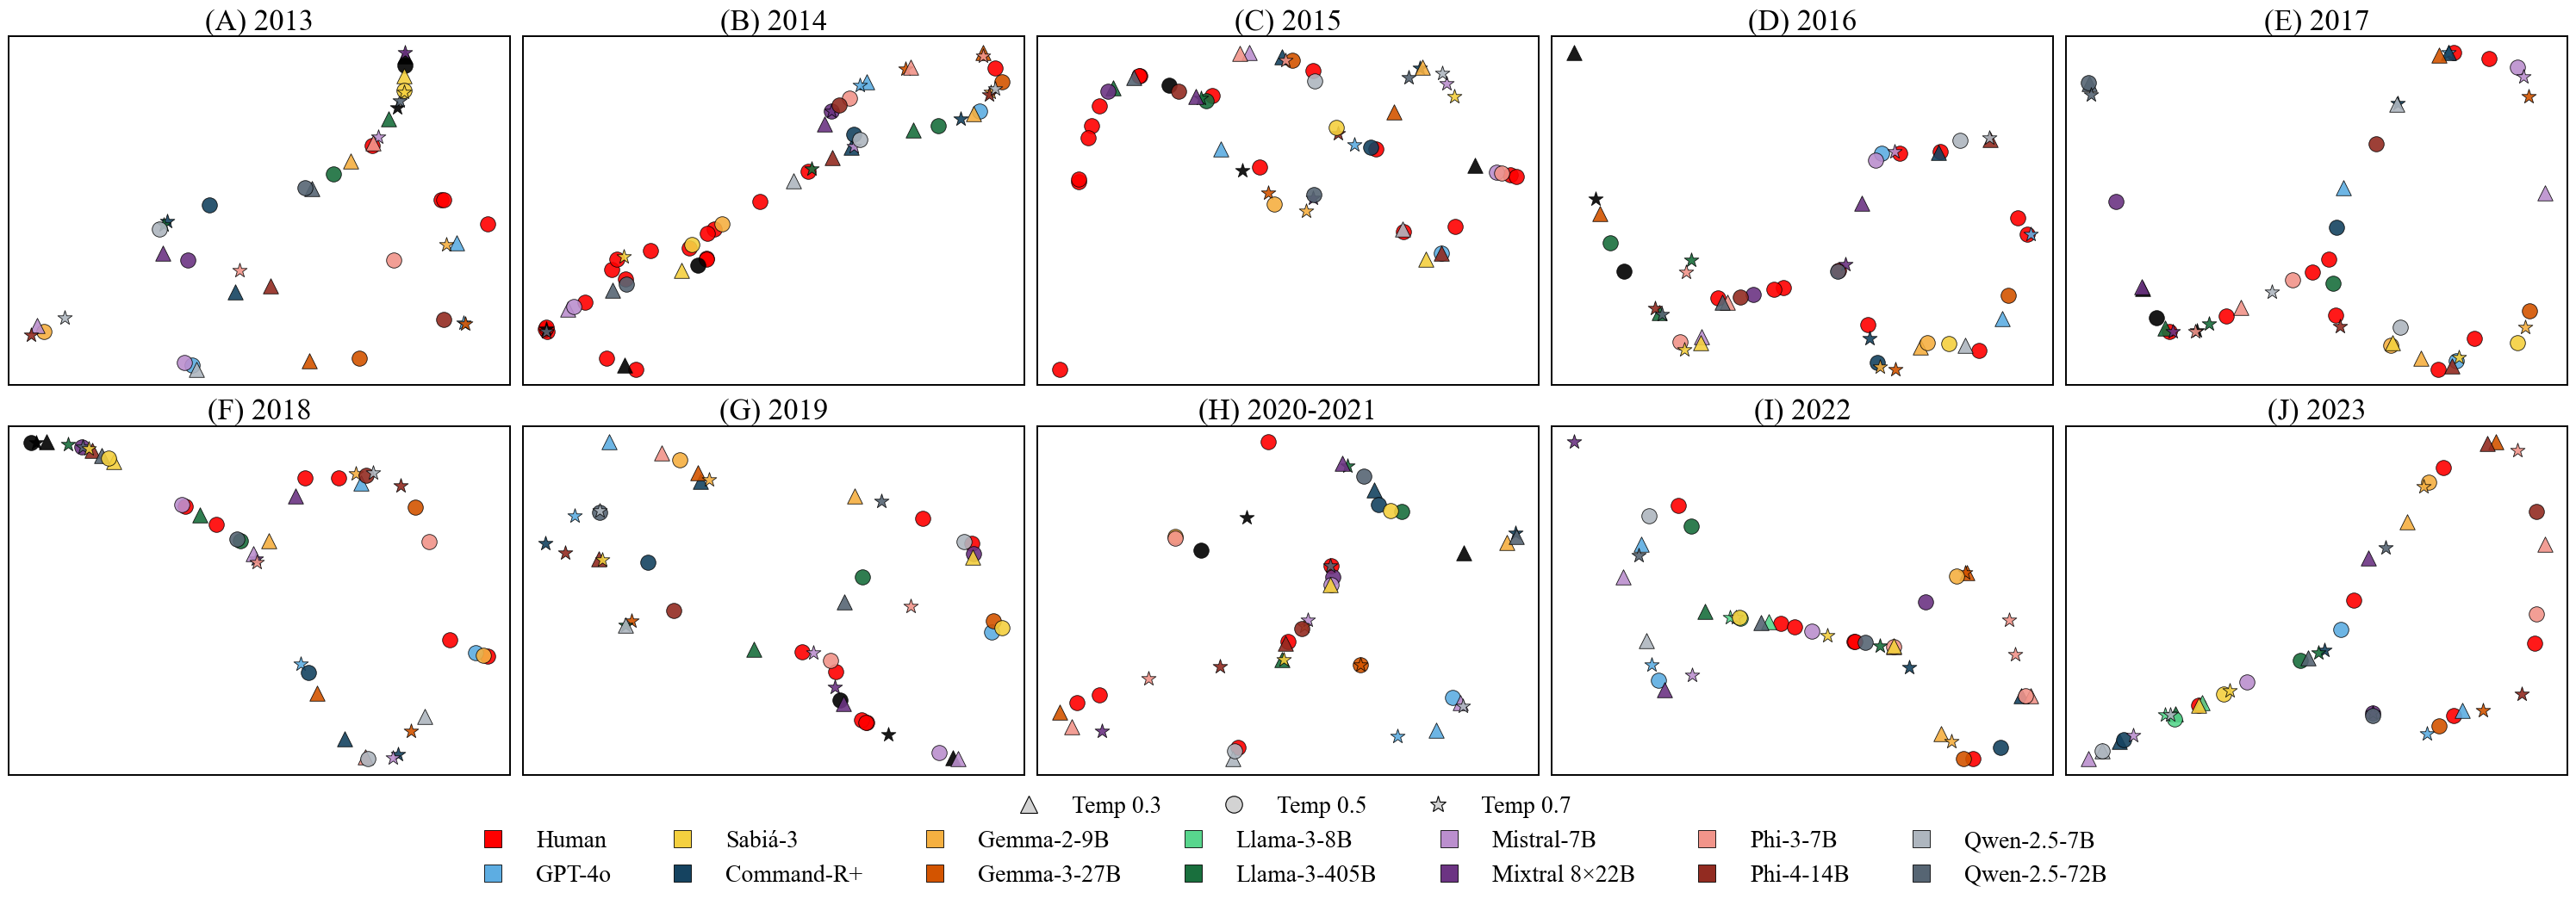

In [ ]:
# ------------------------------------------------------------
# 0) Configurações de arquivos e parâmetros
# ------------------------------------------------------------
HUMAN_JSON = "candidates_metrics.json"   # ajuste aqui
AUTO_JSON  = "llms_metrics.json"         # ajuste aqui
OUTDIR     = "./tsne_figs"
PERPLEXITY = 30

# ------------------------------------------------------------
# 1) Imports e fonte global
# ------------------------------------------------------------
import json, re, numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from math import ceil
from pathlib import Path
from sklearn.manifold import TSNE
plt.rcParams["font.family"] = "Times New Roman"

# ------------------------------------------------------------
# 2) Regex de modelos
# ------------------------------------------------------------
MODELO_REGEXES = {
    r"command[-_]?r[-_]?plus": "Command-R+",
    r"gemma[-_]?27b":          "Gemma-3-27B",
    r"gemma[-_]?2[-_.]?9b":    "Gemma-2-9B",
    r"gemma[-_]?9b":           "Gemma-2-9B",
    r"llama.*405":             "Llama-3-405B",
    r"llama[-_.]?3\.?1.*8":    "Llama-3.1-8B",
    r"llama[-_]?8b":           "Llama-3-8B",
    r"mixtral.*22b":           "Mixtral 8×22B",
    r"mistral.*7b":            "Mistral-7B",
    r"mixtral[-_]?8x?7b":      "Mistral-7B",
    r"phi[-_.]?3.*":           "Phi-3-7B",
    r"phi[-_.]?4":             "Phi-4-14B",
    r"qwen.*72":               "Qwen-2.5-72B",
    r"qwen.*7b":               "Qwen-2.5-7B",
    r"sabia3":                 "Sabiá-3",
    r"gpt4o":                  "GPT-4o",
}
TEMP_RE   = re.compile(r"temp[_\-]?(\d{1,2})", re.I)
YEAR_HEAD = re.compile(r"\d{4}")

unknown_models = set()

def detect_model(label):
    for pat, name in MODELO_REGEXES.items():
        if re.search(pat, label, re.I):
            return name
    unknown_models.add(label)
    return "Unknown-Model"

def extract_temp(label):
    m = TEMP_RE.search(label)
    return int(m.group(1)) if m else None

def load_json(path, is_human):
    with open(path, encoding="utf-8") as f:
        raw = json.load(f)
    return pd.DataFrame([{
        "key":   k,
        "year":  str(v["year"]),
        "is_human": is_human,
        "label": "Human" if is_human else detect_model(k),
        "temp":  None if is_human else extract_temp(k),
        **v["metrics"],
    } for k, v in raw.items()])

# ------------------------------------------------------------
# 3) Carrega e pré-processa dados
# ------------------------------------------------------------
df = pd.concat([load_json(HUMAN_JSON, True),
                load_json(AUTO_JSON,  False)],
               ignore_index=True)

df = df[~df['key'].str.contains(r"phi\s*vision", case=False, na=False)]

if unknown_models:
    print("Unknown-Model keys:", *sorted(unknown_models), sep="\n  • ")

metric_cols = [c for c in df.columns if c not in ("key","year","is_human","label","temp")]
metric_cols = [c for c in metric_cols if not np.isclose(df[c].fillna(0), 0).all()]
X = (
    df[metric_cols]
    .replace({0.0: np.nan, -0.0: np.nan})
    .apply(lambda col: col.fillna(col.mean()), axis=0)
)

# ------------------------------------------------------------
# 4) Cores fixas e símbolos de temperatura
# ------------------------------------------------------------
COLOR_MAP = {
    # -- Humanos
    "Human":          "#FF0000",          # vermelho

    # -- Modelos
    "GPT-4o":         "#5DADE2",          # azul claro
    "Sabiá-3":        "#F4D03F",          # amarelo
    "Command-R+":     "#154360",          # azul escuro

    "Gemma-2-9B":     "#F5B041",          # laranja claro
    "Gemma-3-27B":    "#D35400",          # laranja escuro

    "Llama-3-8B":     "#58D68D",          # verde claro
    "Llama-3-405B":   "#196F3D",          # verde escuro

    "Mistral-7B":     "#BB8FCE",          # roxo claro
    "Mixtral 8×22B":  "#6C3483",          # roxo escuro

    "Phi-3-7B":       "#F1948A",          # rosa claro
    "Phi-4-14B":      "#922B21",          # rosa escuro

    "Qwen-2.5-7B":    "#AEB6BF",          # cinza claro
    "Qwen-2.5-72B":   "#566573",          # cinza escuro
}

# marcador por temperatura
MARKER = {None: "o", 3: "^", 5: "o", 7: "*"}
DEFAULT_MARKER = "s"

def marker_for(temp):
    return MARKER.get(temp, DEFAULT_MARKER)

# ------------------------------------------------------------
# 5) Executa t-SNE por ano
# ------------------------------------------------------------
Path(OUTDIR).mkdir(exist_ok=True)
letters = "ABCDEFGHIJKLMNOPQRSTUVWXYZ"
order_key = lambda y: int(YEAR_HEAD.search(y).group()) if YEAR_HEAD.search(y) else 9999

year_panels = []
for yr in sorted(df.year.unique(), key=order_key):
    sub = df[df.year == yr].copy()
    coords = TSNE(
        n_components=2,
        perplexity=min(PERPLEXITY, max(2, len(sub) - 1)),
        learning_rate="auto",
        init="random",
        random_state=42,
    ).fit_transform(X.loc[sub.index])
    sub[["x", "y"]] = coords
    year_panels.append(sub)

# ------------------------------------------------------------
# 6) Painel 2 × 5
# ------------------------------------------------------------
ncols, nrows = 5, 2
fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 5*nrows), squeeze=False)
for ax in axes.flatten():
    ax.set_xticks([]); ax.set_yticks([])

for idx, (ax, panel) in enumerate(zip(axes.flatten(), year_panels)):
    for _, r in panel.iterrows():
        ax.scatter(
            r.x, r.y,
            s=160,
            color=COLOR_MAP.get(r.label, "#000000"),
            marker=marker_for(r.temp),
            edgecolor="k",
            linewidth=0.6,
            alpha=0.9,
        )
    ax.set_title(f"({letters[idx]}) {panel.year.iloc[0]}", fontsize=25, pad=6)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor("black")
        spine.set_linewidth(1.4)

for ax in axes.flatten()[len(year_panels):]:
    ax.axis("off")

# ------------------------------------------------------------
# 7) Legendas
# ------------------------------------------------------------
# 7.1 Temperaturas (linha de cima)
temp_handles = [
    plt.Line2D([], [], marker=m, linestyle="", markersize=14,
               markerfacecolor="lightgray", markeredgecolor="k", markeredgewidth=0.8)
    for m in ["^", "o", "*"]
]
fig.legend(
    temp_handles, ["Temp 0.3", "Temp 0.5", "Temp 0.7"],
    frameon=False, loc="lower center",
    bbox_to_anchor=(0.5, -0.06), ncol=3, fontsize=20,
)

# 7.2 Modelos (duas linhas abaixo) – QUADRADINHOS PEQUENOS
from matplotlib.lines import Line2D       # ← import para Line2D

desired_order = [
    "Human",
    "GPT-4o", "Sabiá-3", "Command-R+",
    "Gemma-2-9B", "Gemma-3-27B",
    "Llama-3-8B", "Llama-3-405B",
    "Mistral-7B", "Mixtral 8×22B",
    "Phi-3-7B", "Phi-4-14B",
    "Qwen-2.5-7B", "Qwen-2.5-72B",
]
model_labels = [lbl for lbl in desired_order if lbl in df.label.unique()]

# quadrado ('s') com tamanho menor (10) e contorno preto
model_handles = [
    Line2D([], [], marker='s', linestyle='', markersize=14,
           markerfacecolor=COLOR_MAP[lbl], markeredgecolor='k', markeredgewidth=0.6)
    for lbl in model_labels
]

n_cols = ceil(len(model_labels) / 2)  # quebra em 2 linhas
fig.legend(
    model_handles, model_labels,
    frameon=False, loc="lower center",
    bbox_to_anchor=(0.5, -0.14),
    ncol=n_cols, fontsize=20,
)


plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

# ------------------------------------------------------------
# 8) Salva painel em alta resolução
# ------------------------------------------------------------
fig.savefig(Path(OUTDIR) / "tsne_all_years.png", dpi=600, bbox_inches="tight")
plt.close()


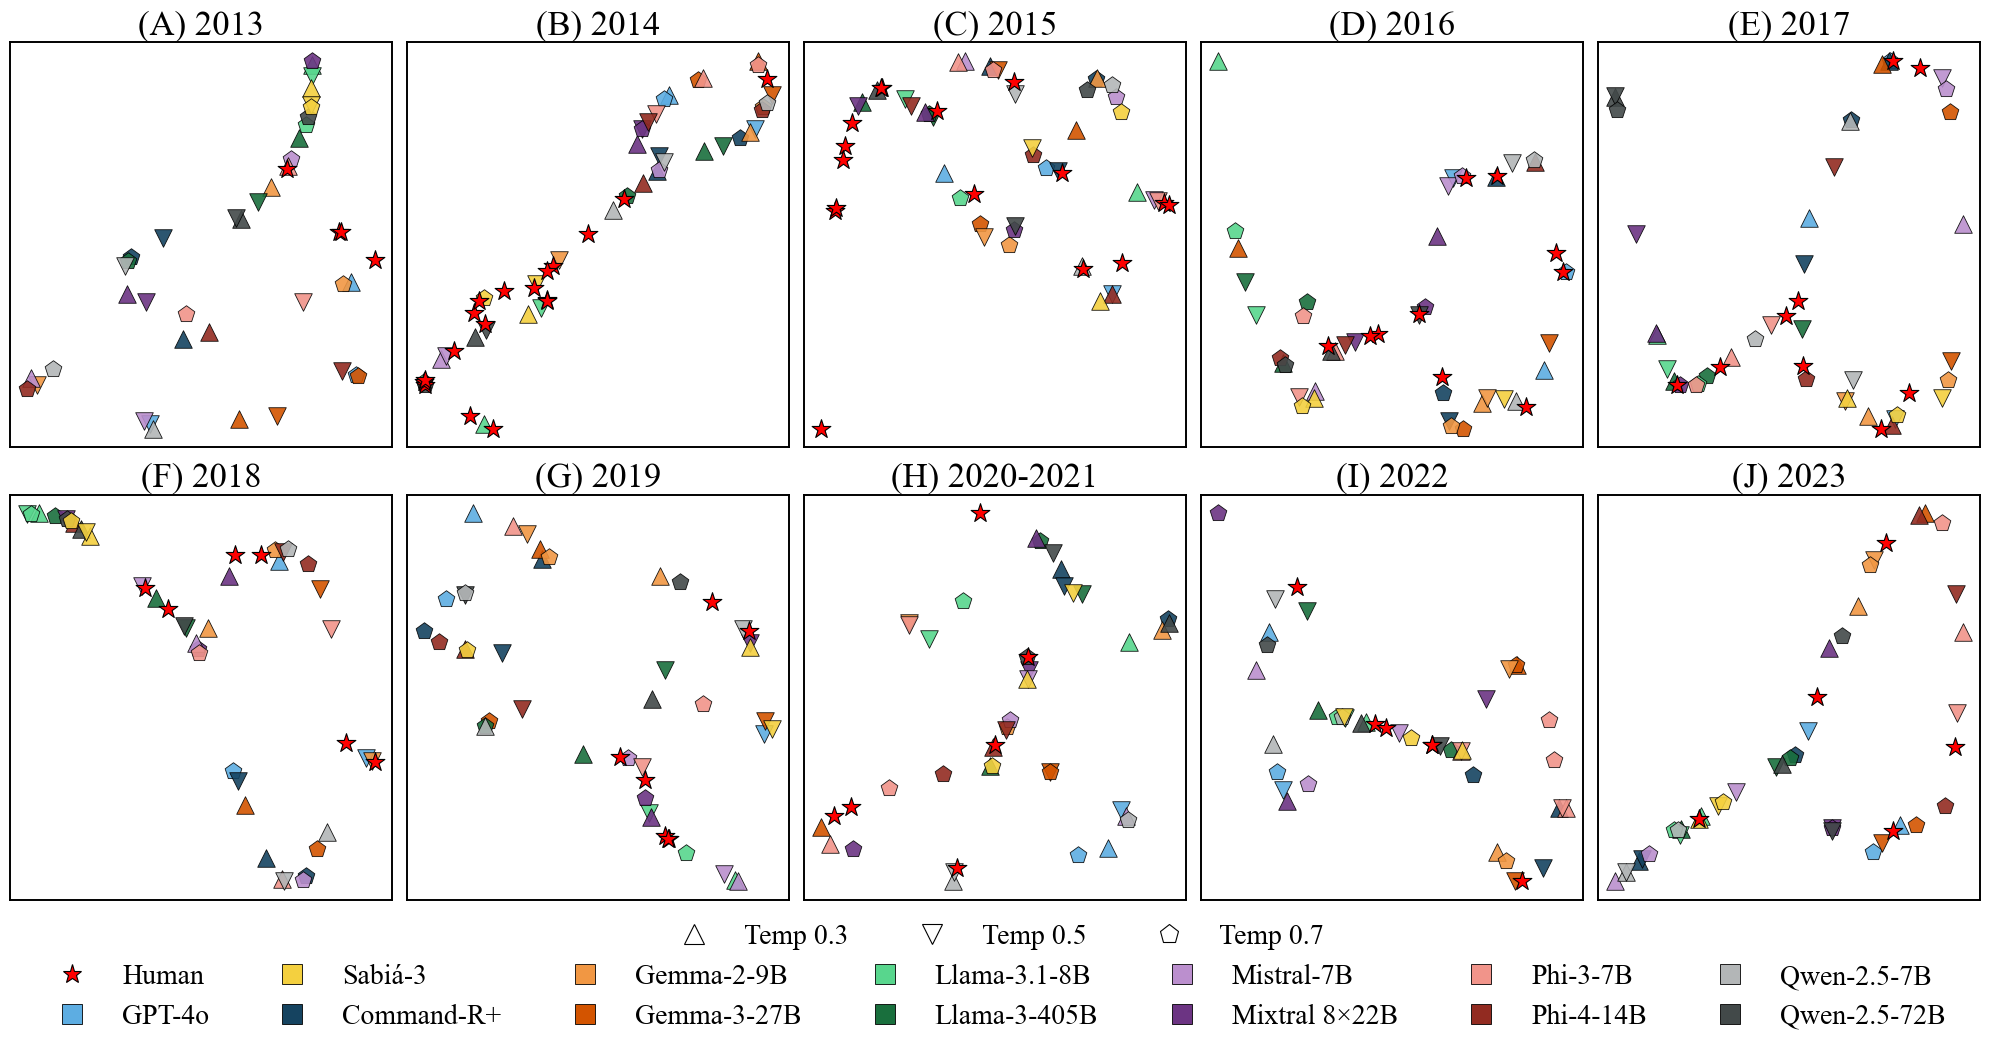

In [18]:
# ------------------------------------------------------------
# 0) Configurações
# ------------------------------------------------------------
HUMAN_JSON = "candidates_metrics.json"   # ajuste aqui
AUTO_JSON  = "llms_metrics.json"         # ajuste aqui
OUTDIR     = "./tsne_figs"
PERPLEXITY = 30

# ------------------------------------------------------------
# 1) Imports e fonte global
# ------------------------------------------------------------
import json, re, numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from math import ceil
from pathlib import Path
from sklearn.manifold import TSNE
from matplotlib.lines import Line2D
plt.rcParams["font.family"] = "Times New Roman"

# ------------------------------------------------------------
# 2) Regex de modelos
# ------------------------------------------------------------
MODELO_REGEXES = {
    r"command[-_]?r[-_]?plus": "Command-R+",
    r"gemma[-_]?27b":          "Gemma-3-27B",
    r"gemma[-_]?2[-_.]?9b":    "Gemma-2-9B",
    r"gemma[-_]?9b":           "Gemma-2-9B",
    r"llama.*405":             "Llama-3-405B",
    r"llama[-_.]?3\.?1.*8":    "Llama-3.1-8B",
    r"llama[-_]?8b":           "Llama-3.1-8B",
    r"mixtral.*22b":           "Mixtral 8×22B",
    r"mistral.*7b":            "Mistral-7B",
    r"mixtral[-_]?8x?7b":      "Mistral-7B",
    r"phi[-_.]?3.*":           "Phi-3-7B",
    r"phi[-_.]?4":             "Phi-4-14B",
    r"qwen.*72":               "Qwen-2.5-72B",
    r"qwen.*7b":               "Qwen-2.5-7B",
    r"sabia3":                 "Sabiá-3",
    r"gpt4o":                  "GPT-4o",
}
TEMP_RE   = re.compile(r"temp[_\-]?(\d{1,2})", re.I)
YEAR_HEAD = re.compile(r"\d{4}")

unknown_models = set()

def detect_model(label):
    for pat, name in MODELO_REGEXES.items():
        if re.search(pat, label, re.I):
            return name
    unknown_models.add(label)
    return "Unknown-Model"

def extract_temp(label):
    m = TEMP_RE.search(label)
    return int(m.group(1)) if m else None

def load_json(path, is_human):
    with open(path, encoding="utf-8") as f:
        raw = json.load(f)
    return pd.DataFrame([{
        "key":   k,
        "year":  str(v["year"]),
        "is_human": is_human,
        "label": "Human" if is_human else detect_model(k),
        "temp":  None if is_human else extract_temp(k),
        **v["metrics"],
    } for k, v in raw.items()])

# ------------------------------------------------------------
# 3) Carrega e processa dados
# ------------------------------------------------------------
df = pd.concat([load_json(HUMAN_JSON, True),
                load_json(AUTO_JSON,  False)],
               ignore_index=True)

df = df[~df['key'].str.contains(r"phi\s*vision", case=False, na=False)]

if unknown_models:
    print("Unknown-Model keys:", *sorted(unknown_models), sep="\n  • ")

metric_cols = [c for c in df.columns if c not in ("key","year","is_human","label","temp")]
metric_cols = [c for c in metric_cols if not np.isclose(df[c].fillna(0), 0).all()]
X = (
    df[metric_cols]
    .replace({0.0: np.nan, -0.0: np.nan})
    .apply(lambda col: col.fillna(col.mean()), axis=0)
)

# ------------------------------------------------------------
# 4) Cores fixas e marcadores
# ------------------------------------------------------------
COLOR_MAP = {
    "Human":          "#FF0000",
    "GPT-4o":         "#5DADE2",
    "Sabiá-3":        "#F4D03F",
    "Command-R+":     "#154360",
    "Gemma-2-9B":     "#F19743",
    "Gemma-3-27B":    "#D35400",
    "Llama-3.1-8B":     "#58D68D",
    "Llama-3-405B":   "#196F3D",
    "Mistral-7B":     "#BB8FCE",
    "Mixtral 8×22B":  "#6C3483",
    "Phi-3-7B":       "#F1948A",
    "Phi-4-14B":      "#922B21",
"Qwen-2.5-7B":   "#B3B6B7",  
"Qwen-2.5-72B":  "#424949"   
}

# marcador por temperatura
MARKER = {None: "s", 3: "^", 5: "v", 7: "p"}  # quadrado / ▲ / ▼ / pentágono
def marker_for(temp):
    return MARKER.get(temp, "s")

# ------------------------------------------------------------
# 5) t-SNE por ano
# ------------------------------------------------------------
Path(OUTDIR).mkdir(exist_ok=True)
letters   = "ABCDEFGHIJKLMNOPQRSTUVWXYZ"
order_key = lambda y: int(YEAR_HEAD.search(y).group()) if YEAR_HEAD.search(y) else 9999

year_panels = []
for yr in sorted(df.year.unique(), key=order_key):
    sub = df[df.year == yr].copy()
    coords = TSNE(
        n_components=2,
        perplexity=min(PERPLEXITY, max(2, len(sub) - 1)),
        learning_rate="auto", init="random", random_state=42
    ).fit_transform(X.loc[sub.index])
    sub[["x", "y"]] = coords
    year_panels.append(sub)

# ------------------------------------------------------------
# 6) Painel 2 × 5
# ------------------------------------------------------------
ncols, nrows = 5, 2
fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 5*nrows), squeeze=False)
for ax in axes.flatten():
    ax.set_xticks([]); ax.set_yticks([])

for idx, (ax, panel) in enumerate(zip(axes.flatten(), year_panels)):
    # 6.1 Modelos não-Human
    non_human = panel[panel.label != "Human"]
    for _, r in non_human.iterrows():
        ax.scatter(
            r.x, r.y, s=160,
            color=COLOR_MAP.get(r.label, "#000000"),
            marker=marker_for(r.temp),
            edgecolor="k", linewidth=0.6, alpha=0.9,
        )
    # 6.2 Human – estrela vermelha sobreposta
    human = panel[panel.label == "Human"]
    for _, r in human.iterrows():
        ax.scatter(
            r.x, r.y, s=200,
            color=COLOR_MAP["Human"],
            marker="*", edgecolor="k", linewidth=0.8,
            alpha=1.0, zorder=10
        )

    ax.set_title(f"({letters[idx]}) {panel.year.iloc[0]}", fontsize=25, pad=6)
    for spine in ax.spines.values():
        spine.set_visible(True); spine.set_edgecolor("black"); spine.set_linewidth(1.4)

for ax in axes.flatten()[len(year_panels):]:
    ax.axis("off")

# ------------------------------------------------------------
# 7) Legendas
# ------------------------------------------------------------
# 7.1 Temperaturas (linha de cima)
temp_handles = [
    Line2D([], [], marker='^', linestyle='', markersize=14,
           markerfacecolor='none', markeredgecolor='k', markeredgewidth=0.8),
    Line2D([], [], marker='v', linestyle='', markersize=14,
           markerfacecolor='none', markeredgecolor='k', markeredgewidth=0.8),
    Line2D([], [], marker='p', linestyle='', markersize=14,
           markerfacecolor='none', markeredgecolor='k', markeredgewidth=0.8),
]
fig.legend(
    temp_handles, ["Temp 0.3", "Temp 0.5", "Temp 0.7"],
    frameon=False, loc="lower center",
    bbox_to_anchor=(0.5, -0.06), ncol=3, fontsize=20,
)

# 7.2 Modelos (duas linhas; Human estrela, demais quadradinhos)
desired_order = [
    "Human", "GPT-4o", "Sabiá-3", "Command-R+",
    "Gemma-2-9B", "Gemma-3-27B", "Llama-3.1-8B", "Llama-3-405B",
    "Mistral-7B", "Mixtral 8×22B", "Phi-3-7B", "Phi-4-14B",
    "Qwen-2.5-7B", "Qwen-2.5-72B",
]
model_labels = [lbl for lbl in desired_order if lbl in df.label.unique()]

model_handles = []
for lbl in model_labels:
    if lbl == "Human":  # estrela
        model_handles.append(
            Line2D([], [], marker='*', linestyle='', markersize=14,
                   markerfacecolor=COLOR_MAP["Human"],
                   markeredgecolor='k', markeredgewidth=0.8)
        )
    else:               # quadradinho
        model_handles.append(
            Line2D([], [], marker='s', linestyle='', markersize=14,
                   markerfacecolor=COLOR_MAP[lbl],
                   markeredgecolor='k', markeredgewidth=0.6)
        )

n_cols = ceil(len(model_labels) / 2)
fig.legend(
    model_handles, model_labels,
    frameon=False, loc="lower center",
    bbox_to_anchor=(0.5, -0.14), ncol=n_cols, fontsize=20,
)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

# ------------------------------------------------------------
# 8) Salva painel em alta resolução
# ------------------------------------------------------------
Path(OUTDIR).mkdir(parents=True, exist_ok=True)
fig.savefig(Path(OUTDIR) / "tsne_all_years.png", dpi=600, bbox_inches="tight")
plt.close()



──────── Distâncias de cada Humano para TODOS os LLMs (ordenadas) ────────

Ano 2013:
Humano: 2013_filipe_brum_cunha
   → GPT-4o           dist = 0.26
   → Command-R+       dist = 0.29
   → Llama-3-405B     dist = 0.29
   → Gemma-2-9B       dist = 0.30
   → Qwen-2.5-7B      dist = 0.30
   → Command-R+       dist = 0.35
   → Mixtral 8×22B    dist = 0.50
   → Qwen-2.5-72B     dist = 0.51
   → Phi-3-7B         dist = 0.51
   → Qwen-2.5-72B     dist = 0.52
   → Mixtral 8×22B    dist = 0.57
   → Phi-3-7B         dist = 0.68
   → Llama-3-405B     dist = 0.69
   → Gemma-2-9B       dist = 0.86
   → Phi-4-14B        dist = 0.88
   → Command-R+       dist = 0.97
   → Phi-3-7B         dist = 1.12
   → Mistral-7B       dist = 1.19
   → Phi-4-14B        dist = 1.31
   → Qwen-2.5-7B      dist = 1.35
   → GPT-4o           dist = 1.37
   → Gemma-3-27B      dist = 1.38
   → Llama-3-405B     dist = 1.44
   → Mistral-7B       dist = 1.45
   → Gemma-2-9B       dist = 1.53
   → Phi-4-14B        dist = 1.5

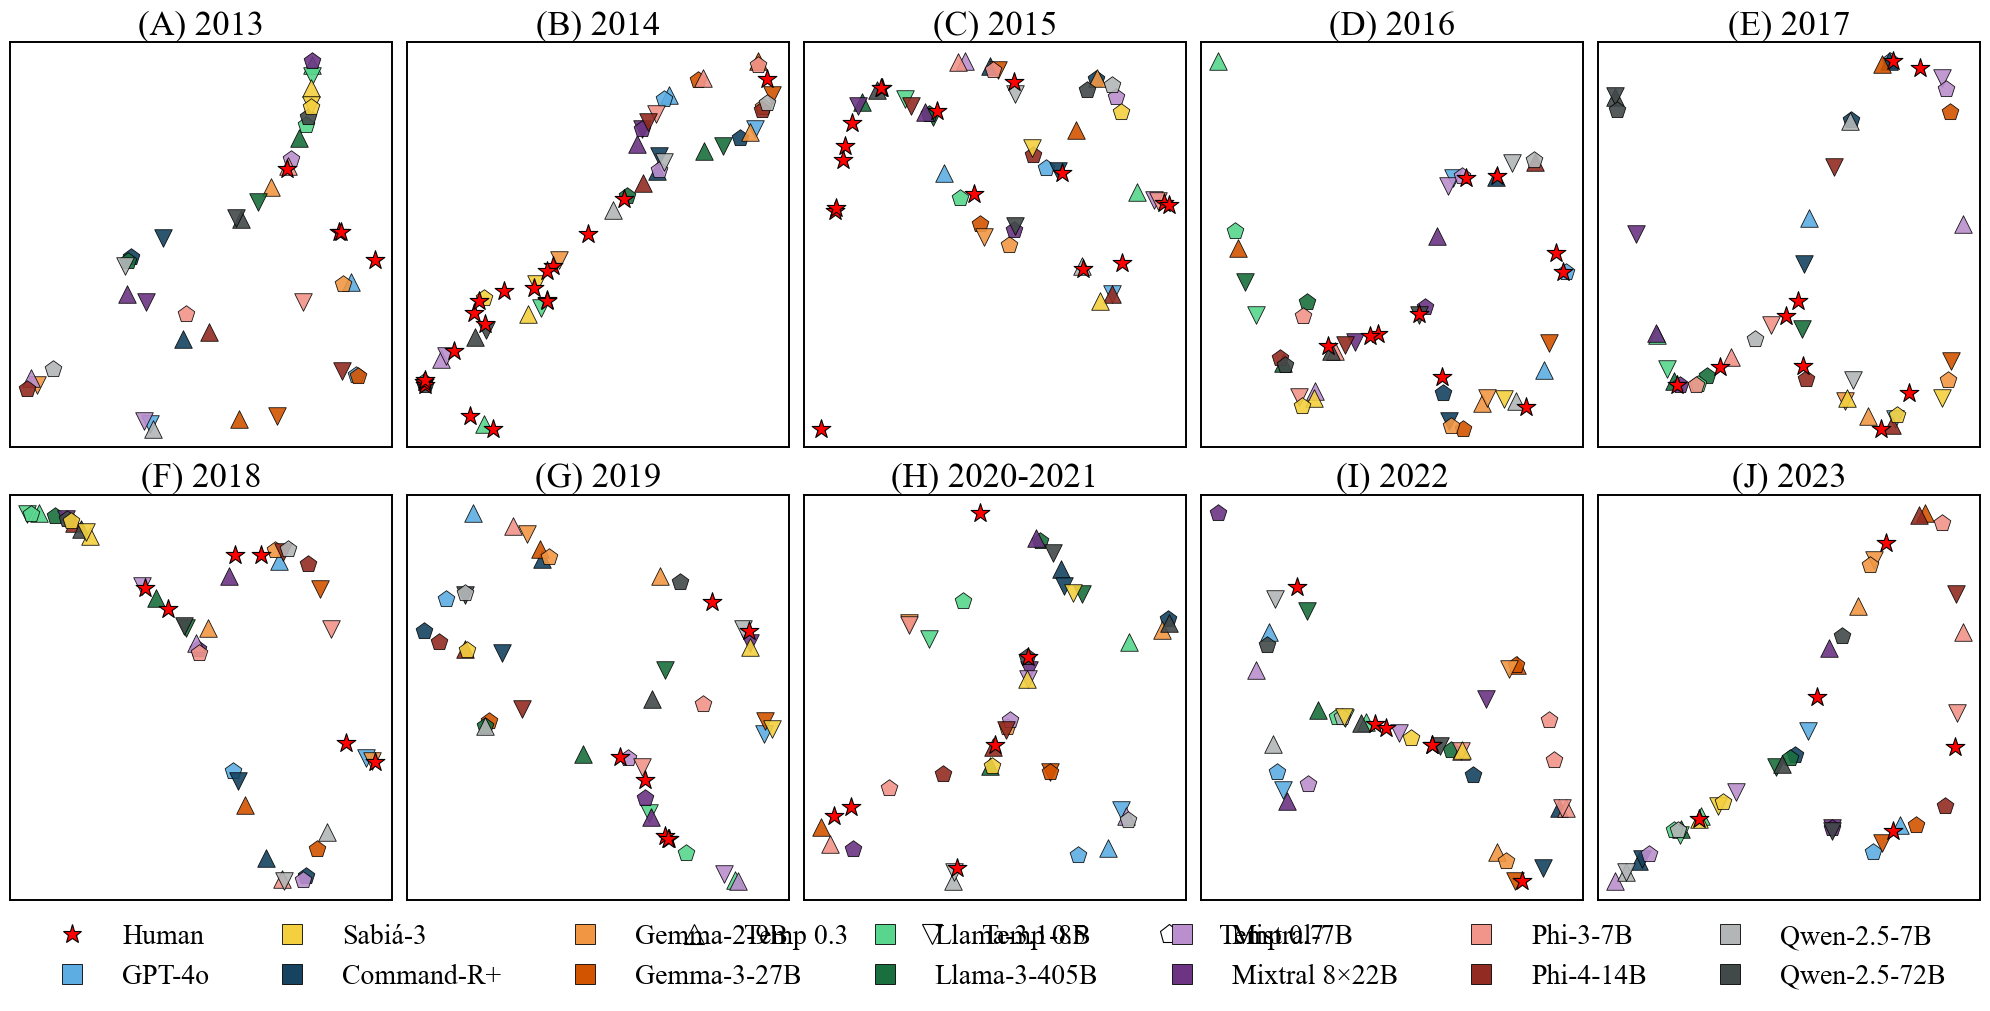

In [7]:
# ------------------------------------------------------------
# 0) Configurações
# ------------------------------------------------------------
HUMAN_JSON = "candidates_metrics.json"   # ajuste aqui
AUTO_JSON  = "llms_metrics.json"         # ajuste aqui
OUTDIR     = "./tsne_figs"
PERPLEXITY = 30

# ------------------------------------------------------------
# 1) Imports e fonte global
# ------------------------------------------------------------
import json, re, numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from math import ceil
from pathlib import Path
from sklearn.manifold import TSNE
from matplotlib.lines import Line2D
plt.rcParams["font.family"] = "Times New Roman"

# ------------------------------------------------------------
# 2) Regex de modelos
# ------------------------------------------------------------
MODELO_REGEXES = {
    r"command[-_]?r[-_]?plus": "Command-R+",
    r"gemma[-_]?27b":          "Gemma-3-27B",
    r"gemma[-_]?2[-_.]?9b":    "Gemma-2-9B",
    r"gemma[-_]?9b":           "Gemma-2-9B",
    r"llama.*405":             "Llama-3-405B",
    r"llama[-_.]?3\.?1.*8":    "Llama-3.1-8B",
    r"llama[-_]?8b":           "Llama-3.1-8B",
    r"mixtral.*22b":           "Mixtral 8×22B",
    r"mistral.*7b":            "Mistral-7B",
    r"mixtral[-_]?8x?7b":      "Mistral-7B",
    r"phi[-_.]?3.*":           "Phi-3-7B",
    r"phi[-_.]?4":             "Phi-4-14B",
    r"qwen.*72":               "Qwen-2.5-72B",
    r"qwen.*7b":               "Qwen-2.5-7B",
    r"sabia3":                 "Sabiá-3",
    r"gpt4o":                  "GPT-4o",
}
TEMP_RE   = re.compile(r"temp[_\-]?(\d{1,2})", re.I)
YEAR_HEAD = re.compile(r"\d{4}")

unknown_models = set()

def detect_model(label):
    for pat, name in MODELO_REGEXES.items():
        if re.search(pat, label, re.I):
            return name
    unknown_models.add(label)
    return "Unknown-Model"

def extract_temp(label):
    m = TEMP_RE.search(label)
    return int(m.group(1)) if m else None

def load_json(path, is_human):
    with open(path, encoding="utf-8") as f:
        raw = json.load(f)
    return pd.DataFrame([{
        "key":   k,
        "year":  str(v["year"]),
        "is_human": is_human,
        "label": "Human" if is_human else detect_model(k),
        "temp":  None if is_human else extract_temp(k),
        **v["metrics"],
    } for k, v in raw.items()])

# ------------------------------------------------------------
# 3) Carrega e processa dados
# ------------------------------------------------------------
df = pd.concat([load_json(HUMAN_JSON, True),
                load_json(AUTO_JSON,  False)],
               ignore_index=True)

df = df[~df['key'].str.contains(r"phi\s*vision", case=False, na=False)]

if unknown_models:
    print("Unknown-Model keys:", *sorted(unknown_models), sep="\n  • ")

metric_cols = [c for c in df.columns if c not in ("key","year","is_human","label","temp")]
metric_cols = [c for c in metric_cols if not np.isclose(df[c].fillna(0), 0).all()]
X = (
    df[metric_cols]
    .replace({0.0: np.nan, -0.0: np.nan})
    .apply(lambda col: col.fillna(col.mean()), axis=0)
)

# ------------------------------------------------------------
# 4) Cores fixas e marcadores
# ------------------------------------------------------------
COLOR_MAP = {
    "Human":          "#FF0000",
    "GPT-4o":         "#5DADE2",
    "Sabiá-3":        "#F4D03F",
    "Command-R+":     "#154360",
    "Gemma-2-9B":     "#F19743",
    "Gemma-3-27B":    "#D35400",
    "Llama-3.1-8B":   "#58D68D",
    "Llama-3-405B":   "#196F3D",
    "Mistral-7B":     "#BB8FCE",
    "Mixtral 8×22B":  "#6C3483",
    "Phi-3-7B":       "#F1948A",
    "Phi-4-14B":      "#922B21",
    "Qwen-2.5-7B":    "#B3B6B7",
    "Qwen-2.5-72B":   "#424949",
}

# marcador por temperatura
MARKER = {None: "s", 3: "^", 5: "v", 7: "p"}  # quadrado / ▲ / ▼ / pentágono
def marker_for(temp): return MARKER.get(temp, "s")

# ------------------------------------------------------------
# 5) t-SNE por ano
# ------------------------------------------------------------
Path(OUTDIR).mkdir(exist_ok=True)
letters   = "ABCDEFGHIJKLMNOPQRSTUVWXYZ"
order_key = lambda y: int(YEAR_HEAD.search(y).group()) if YEAR_HEAD.search(y) else 9999

year_panels = []
for yr in sorted(df.year.unique(), key=order_key):
    sub = df[df.year == yr].copy()
    coords = TSNE(
        n_components=2,
        perplexity=min(PERPLEXITY, max(2, len(sub) - 1)),
        learning_rate="auto", init="random", random_state=42
    ).fit_transform(X.loc[sub.index])
    sub[["x", "y"]] = coords
    year_panels.append(sub)

# ------------------------------------------------------------
# 5-b) Lista completa de distâncias para cada Humano
# ------------------------------------------------------------
import math

print("\n──────── Distâncias de cada Humano para TODOS os LLMs (ordenadas) ────────")
for yr, panel in zip(sorted(df.year.unique(), key=order_key), year_panels):
    humans = panel[panel.label == "Human"]
    llms   = panel[panel.label != "Human"]

    print(f"\nAno {yr}:")
    if humans.empty or llms.empty:
        print("  (sem humanos ou sem LLMs neste ano)")
        continue

    for _, h in humans.iterrows():
        # lista (dx, dy) para cada LLM
        delta = llms[['x', 'y']].values - h[['x', 'y']].values
        # calcula distâncias com math.hypot (não depende de NumPy interno)
        dists = [math.hypot(dx, dy) for dx, dy in delta]

        tmp = llms.copy()
        tmp["dist"] = dists
        tmp = tmp.sort_values("dist")

        print(f"Humano: {h['key']}")
        for _, row in tmp.iterrows():
            print(f"   → {row['label']:<15}  dist = {row['dist']:.2f}")



# ------------------------------------------------------------
# 6) Painel 2 × 5 (afunilado horizontalmente)
# ------------------------------------------------------------
ncols, nrows = 5, 2
fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 5*nrows), squeeze=False)
for ax in axes.flatten():
    ax.set_xticks([]); ax.set_yticks([])

for idx, (ax, panel) in enumerate(zip(axes.flatten(), year_panels)):
    non_human = panel[panel.label != "Human"]
    for _, r in non_human.iterrows():
        ax.scatter(r.x, r.y, s=160,
                   color=COLOR_MAP.get(r.label, "#000000"),
                   marker=marker_for(r.temp),
                   edgecolor="k", linewidth=0.6, alpha=0.9)

    for _, r in panel[panel.label == "Human"].iterrows():
        ax.scatter(r.x, r.y, s=200,
                   color=COLOR_MAP["Human"], marker="*",
                   edgecolor="k", linewidth=0.8, alpha=1.0, zorder=10)

    ax.set_title(f"({letters[idx]}) {panel.year.iloc[0]}", fontsize=25, pad=6)
    for spine in ax.spines.values():
        spine.set_visible(True); spine.set_edgecolor("black"); spine.set_linewidth(1.4)

for ax in axes.flatten()[len(year_panels):]:
    ax.axis("off")

# ------------------------------------------------------------
# 7) Legendas
# ------------------------------------------------------------
# Temperaturas
temp_handles = [
    Line2D([], [], marker='^', linestyle='', markersize=14,
           markerfacecolor='none', markeredgecolor='k', markeredgewidth=0.8),
    Line2D([], [], marker='v', linestyle='', markersize=14,
           markerfacecolor='none', markeredgecolor='k', markeredgewidth=0.8),
    Line2D([], [], marker='p', linestyle='', markersize=14,
           markerfacecolor='none', markeredgecolor='k', markeredgewidth=0.8),
]
fig.legend(temp_handles, ["Temp 0.3", "Temp 0.5", "Temp 0.7"],
           frameon=False, loc="lower center",
           bbox_to_anchor=(0.5, -0.06), ncol=3, fontsize=20)

# Modelos
desired_order = [
    "Human", "GPT-4o", "Sabiá-3", "Command-R+",
    "Gemma-2-9B", "Gemma-3-27B",
    "Llama-3.1-8B", "Llama-3-405B",
    "Mistral-7B", "Mixtral 8×22B",
    "Phi-3-7B", "Phi-4-14B",
    "Qwen-2.5-7B", "Qwen-2.5-72B",
]
model_labels = [lbl for lbl in desired_order if lbl in df.label.unique()]

model_handles = []
for lbl in model_labels:
    if lbl == "Human":
        model_handles.append(Line2D([], [], marker='*', linestyle='', markersize=14,
                                    markerfacecolor=COLOR_MAP["Human"],
                                    markeredgecolor='k', markeredgewidth=0.8))
    else:
        model_handles.append(Line2D([], [], marker='s', linestyle='', markersize=14,
                                    markerfacecolor=COLOR_MAP[lbl],
                                    markeredgecolor='k', markeredgewidth=0.6))

n_cols = ceil(len(model_labels) / 2)
fig.legend(model_handles, model_labels,
           frameon=False, loc="lower center",
           bbox_to_anchor=(0.5, -0.10), ncol=n_cols, fontsize=20)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

# ------------------------------------------------------------
# 8) Salva painel
# ------------------------------------------------------------
fig.savefig(Path(OUTDIR) / "tsne_all_years.png", dpi=600, bbox_inches="tight")
plt.close()


C:\Users\gabri\AppData\Local\Temp\ipykernel_7776\1805059259.py:103: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([load_json(HUMAN_JSON, True),



──────── Distâncias de cada Humano para TODOS os LLMs (ordenadas) ────────

Ano 2013:
Humano: 2013_filipe_brum_cunha
   → GPT-4o           dist = 0.26
   → Command-R+       dist = 0.29
   → Llama-3-405B     dist = 0.29
   → Gemma-2-9B       dist = 0.30
   → Qwen-2.5-7B      dist = 0.30
   → Command-R+       dist = 0.35
   → Mixtral 8×22B    dist = 0.50
   → Qwen-2.5-72B     dist = 0.51
   → Phi-3-7B         dist = 0.51
   → Qwen-2.5-72B     dist = 0.52
   → Mixtral 8×22B    dist = 0.57
   → Phi-3-7B         dist = 0.68
   → Llama-3-405B     dist = 0.69
   → Gemma-2-9B       dist = 0.86
   → Phi-4-14B        dist = 0.88
   → Command-R+       dist = 0.97
   → Phi-3-7B         dist = 1.12
   → Mistral-7B       dist = 1.19
   → Phi-4-14B        dist = 1.31
   → Qwen-2.5-7B      dist = 1.35
   → GPT-4o           dist = 1.37
   → Gemma-3-27B      dist = 1.38
   → Llama-3-405B     dist = 1.44
   → Mistral-7B       dist = 1.45
   → Gemma-2-9B       dist = 1.53
   → Phi-4-14B        dist = 1.5

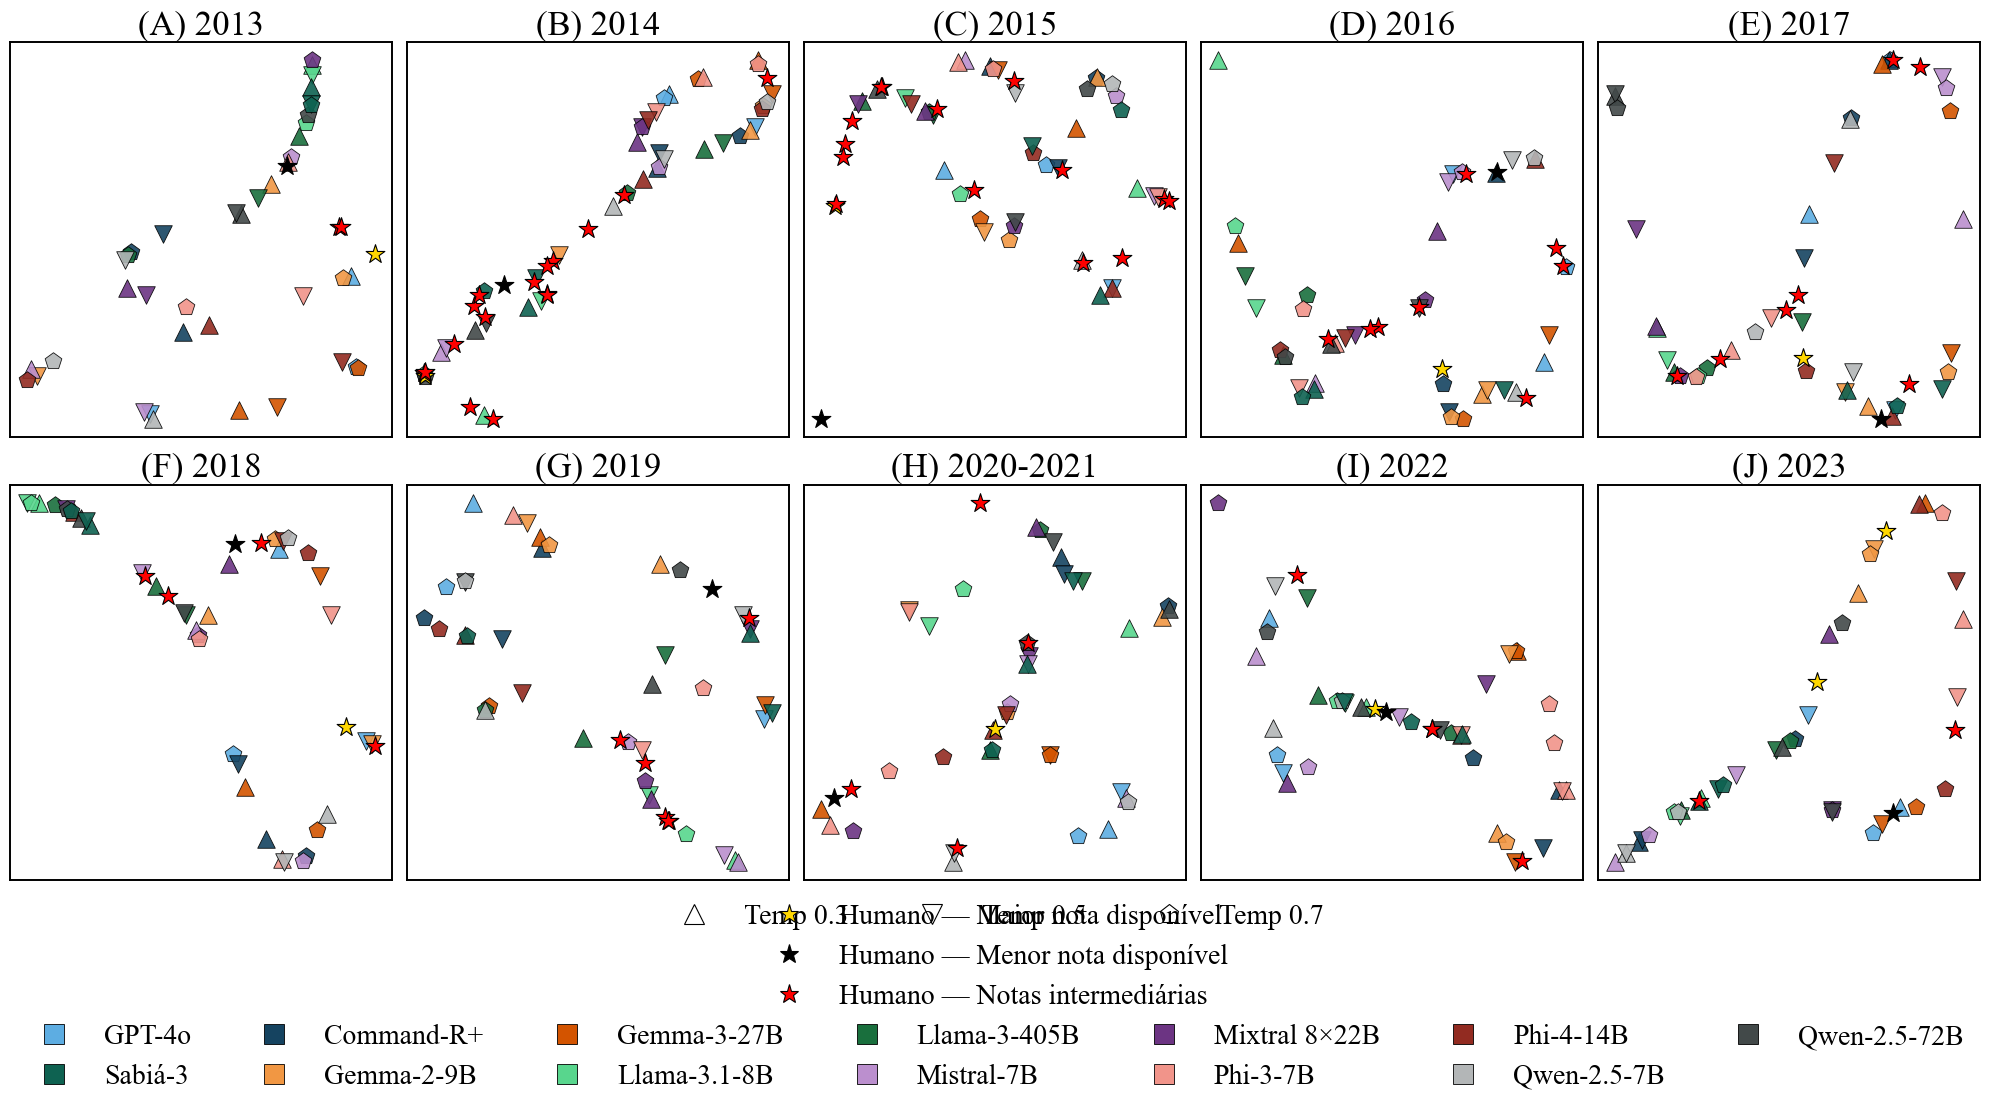

In [4]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-
"""
Painel t-SNE (2 × 5) para comparar LLMs e humanos.
– Cores de estrela indicam nota (grade) dos humanos:
      • ★ amarelo  → maior nota disponível
      • ★ preto    → menor nota disponível
      • ★ vermelho → notas intermediárias
– Forma de marcador indica temperatura do modelo automático.
– Cor do Sabiá-3 foi trocada para verde-escuro para não confundir com amarelo.
"""

# ------------------------------------------------------------
# 0) Configurações
# ------------------------------------------------------------
HUMAN_JSON = "candidates_metrics_notes.json"   # ajuste aqui
AUTO_JSON  = "llms_metrics.json"         # ajuste aqui
OUTDIR     = "./tsne_figs"
PERPLEXITY = 30

# ------------------------------------------------------------
# 1) Imports e fonte global
# ------------------------------------------------------------
import json, re, math, numpy as np, pandas as pd
import matplotlib.pyplot as plt; import seaborn as sns
from math import ceil
from pathlib import Path
from sklearn.manifold import TSNE
from matplotlib.lines import Line2D
plt.rcParams["font.family"] = "Times New Roman"

# ★ cores das estrelas (humanos)
STAR_MAX = "#FFD700"   # amarelo-ouro  – maior nota
STAR_MIN = "#000000"   # preto         – menor nota
STAR_MID = "#FF0000"   # vermelho      – notas intermediárias


def star_color(grade: float, gmin: float, gmax: float) -> str:
    """Cor da estrela conforme nota e extremos do ano."""
    if grade == gmax:
        return STAR_MAX
    if grade == gmin:
        return STAR_MIN
    return STAR_MID

# ------------------------------------------------------------
# 2) Regex de modelos
# ------------------------------------------------------------
MODELO_REGEXES = {
    r"command[-_]?r[-_]?plus": "Command-R+",
    r"gemma[-_]?27b":          "Gemma-3-27B",
    r"gemma[-_]?2[-_.]?9b":    "Gemma-2-9B",
    r"gemma[-_]?9b":           "Gemma-2-9B",
    r"llama.*405":             "Llama-3-405B",
    r"llama[-_.]?3\.?1.*8":    "Llama-3.1-8B",
    r"llama[-_]?8b":           "Llama-3.1-8B",
    r"mixtral.*22b":           "Mixtral 8×22B",
    r"mistral.*7b":            "Mistral-7B",
    r"mixtral[-_]?8x?7b":      "Mistral-7B",
    r"phi[-_.]?3.*":           "Phi-3-7B",
    r"phi[-_.]?4":             "Phi-4-14B",
    r"qwen.*72":               "Qwen-2.5-72B",
    r"qwen.*7b":               "Qwen-2.5-7B",
    r"sabia3":                 "Sabiá-3",
    r"gpt4o":                  "GPT-4o",
}
TEMP_RE   = re.compile(r"temp[_\-]?(\d{1,2})", re.I)
YEAR_HEAD = re.compile(r"\d{4}")

unknown_models = set()

# ------------------------------------------------------------
# 3) Funções auxiliares
# ------------------------------------------------------------
def detect_model(label: str) -> str:
    for pat, name in MODELO_REGEXES.items():
        if re.search(pat, label, re.I):
            return name
    unknown_models.add(label)
    return "Unknown-Model"

def extract_temp(label: str):
    m = TEMP_RE.search(label)
    return int(m.group(1)) if m else None

def load_json(path: str, is_human: bool) -> pd.DataFrame:
    with open(path, encoding="utf-8") as f:
        raw = json.load(f)

    return pd.DataFrame([{
        "key":      k,
        "year":     str(v["year"]),
        "is_human": is_human,
        "label":    "Human" if is_human else detect_model(k),
        "temp":     None if is_human else extract_temp(k),
        "grade":    v.get("grade"),            # ← importa a nota
        **v["metrics"],
    } for k, v in raw.items()])

# ------------------------------------------------------------
# 4) Carrega e processa dados
# ------------------------------------------------------------
df = pd.concat([load_json(HUMAN_JSON, True),
                load_json(AUTO_JSON,  False)],
               ignore_index=True)

# remove entradas de visão phi (se houver)
df = df[~df['key'].str.contains(r"phi\s*vision", case=False, na=False)]

if unknown_models:
    print("Unknown-Model keys:", *sorted(unknown_models), sep="\n  • ")

metric_cols = [c for c in df.columns
               if c not in ("key", "year", "is_human", "label",
                            "temp", "grade")]
metric_cols = [c for c in metric_cols
               if not np.isclose(df[c].fillna(0), 0).all()]

# preenche NaNs com a média da coluna antes do t-SNE
X = (df[metric_cols]
      .replace({0.0: np.nan, -0.0: np.nan})
      .apply(lambda col: col.fillna(col.mean()), axis=0))

# ------------------------------------------------------------
# 5) Cores fixas e marcadores
# ------------------------------------------------------------
COLOR_MAP = {
    "Human":          STAR_MID,      # cor genérica (não usada no scatter)
    "GPT-4o":         "#5DADE2",
    "Sabiá-3":        "#0E6251",     # verde-escuro (mudado)
    "Command-R+":     "#154360",
    "Gemma-2-9B":     "#F19743",
    "Gemma-3-27B":    "#D35400",
    "Llama-3.1-8B":   "#58D68D",
    "Llama-3-405B":   "#196F3D",
    "Mistral-7B":     "#BB8FCE",
    "Mixtral 8×22B":  "#6C3483",
    "Phi-3-7B":       "#F1948A",
    "Phi-4-14B":      "#922B21",
    "Qwen-2.5-7B":    "#B3B6B7",
    "Qwen-2.5-72B":   "#424949",
}

# marcador por temperatura
MARKER = {None: "s", 3: "^", 5: "v", 7: "p"}  # quadrado / ▲ / ▼ / pentágono
def marker_for(temp): return MARKER.get(temp, "s")

# ------------------------------------------------------------
# 6) t-SNE por ano
# ------------------------------------------------------------
Path(OUTDIR).mkdir(exist_ok=True)
letters   = "ABCDEFGHIJKLMNOPQRSTUVWXYZ"
order_key = lambda y: int(YEAR_HEAD.search(y).group()) if YEAR_HEAD.search(y) else 9999

year_panels = []
for yr in sorted(df.year.unique(), key=order_key):
    sub = df[df.year == yr].copy()
    coords = TSNE(
        n_components=2,
        perplexity=min(PERPLEXITY, max(2, len(sub) - 1)),
        learning_rate="auto", init="random", random_state=42
    ).fit_transform(X.loc[sub.index])
    sub[["x", "y"]] = coords
    year_panels.append(sub)

# ------------------------------------------------------------
# 6-b) Distâncias dos humanos para LLMs (debug)
# ------------------------------------------------------------
print("\n──────── Distâncias de cada Humano para TODOS os LLMs (ordenadas) ────────")
for yr, panel in zip(sorted(df.year.unique(), key=order_key), year_panels):
    humans = panel[panel.label == "Human"]
    llms   = panel[panel.label != "Human"]

    print(f"\nAno {yr}:")
    if humans.empty or llms.empty:
        print("  (sem humanos ou sem LLMs neste ano)")
        continue

    for _, h in humans.iterrows():
        # distâncias euclidianas
        delta = llms[['x', 'y']].values - h[['x', 'y']].values
        dists = [math.hypot(dx, dy) for dx, dy in delta]

        tmp = llms.copy()
        tmp["dist"] = dists
        tmp = tmp.sort_values("dist")

        print(f"Humano: {h['key']}")
        for _, row in tmp.iterrows():
            print(f"   → {row['label']:<15}  dist = {row['dist']:.2f}")

# ------------------------------------------------------------
# 7) Gera painel 2 × 5
# ------------------------------------------------------------
ncols, nrows = 5, 2
fig, axes = plt.subplots(nrows, ncols,
                         figsize=(4*ncols, 5*nrows),
                         squeeze=False)

for ax in axes.flatten():
    ax.set_xticks([]); ax.set_yticks([])

for idx, (ax, panel) in enumerate(zip(axes.flatten(), year_panels)):
    # extremas de nota **por ano**
    g_min, g_max = (panel.loc[panel.is_human, "grade"].min(),
                    panel.loc[panel.is_human, "grade"].max())

    # LLMs
    for _, r in panel[panel.label != "Human"].iterrows():
        ax.scatter(r.x, r.y, s=160,
                   color=COLOR_MAP.get(r.label, "#000000"),
                   marker=marker_for(r.temp),
                   edgecolor="k", linewidth=0.6, alpha=0.9)

    # Humanos
    for _, r in panel[panel.label == "Human"].iterrows():
        ax.scatter(r.x, r.y, s=200,
                   color=star_color(r.grade, g_min, g_max),   # ★ cor por nota
                   marker="*",
                   edgecolor="k", linewidth=0.8, alpha=1.0, zorder=10)

    ax.set_title(f"({letters[idx]}) {panel.year.iloc[0]}",
                 fontsize=25, pad=6)

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor("black")
        spine.set_linewidth(1.4)

# desliga eixos vazios (caso < 10 painéis)
for ax in axes.flatten()[len(year_panels):]:
    ax.axis("off")

# ------------------------------------------------------------
# 8) Legendas
# ------------------------------------------------------------
# Temperaturas (marcadores ocos)
temp_handles = [
    Line2D([], [], marker='^', linestyle='', markersize=14,
           markerfacecolor='none', markeredgecolor='k', markeredgewidth=0.8),
    Line2D([], [], marker='v', linestyle='', markersize=14,
           markerfacecolor='none', markeredgecolor='k', markeredgewidth=0.8),
    Line2D([], [], marker='p', linestyle='', markersize=14,
           markerfacecolor='none', markeredgecolor='k', markeredgewidth=0.8),
]
fig.legend(temp_handles, ["Temp 0.3", "Temp 0.5", "Temp 0.7"],
           frameon=False, loc="lower center",
           bbox_to_anchor=(0.5, -0.06), ncol=3, fontsize=20)

# Estrelas (notas humanas)
nota_handles = [
    Line2D([], [], marker='*', linestyle='', markersize=14,
           markerfacecolor=STAR_MAX, markeredgecolor='k', markeredgewidth=0.8),
    Line2D([], [], marker='*', linestyle='', markersize=14,
           markerfacecolor=STAR_MIN, markeredgecolor='k', markeredgewidth=0.8),
    Line2D([], [], marker='*', linestyle='', markersize=14,
           markerfacecolor=STAR_MID, markeredgecolor='k', markeredgewidth=0.8),
]
fig.legend(nota_handles,
           ["Humano — Maior nota disponível",
            "Humano — Menor nota disponível",
            "Humano — Notas intermediárias"],
           frameon=False, loc="lower center",
           bbox_to_anchor=(0.5, -0.14), ncol=1, fontsize=20)

# Modelos (quadrados / etc.)
desired_order = [
    "GPT-4o", "Sabiá-3", "Command-R+",
    "Gemma-2-9B", "Gemma-3-27B",
    "Llama-3.1-8B", "Llama-3-405B",
    "Mistral-7B", "Mixtral 8×22B",
    "Phi-3-7B", "Phi-4-14B",
    "Qwen-2.5-7B", "Qwen-2.5-72B",
]
model_labels = [lbl for lbl in desired_order if lbl in df.label.unique()]

model_handles = [Line2D([], [], marker='s', linestyle='',
                        markersize=14,
                        markerfacecolor=COLOR_MAP[lbl],
                        markeredgecolor='k', markeredgewidth=0.6)
                 for lbl in model_labels]

n_cols = ceil(len(model_handles) / 2) or 1
fig.legend(model_handles, model_labels,
           frameon=False, loc="lower center",
           bbox_to_anchor=(0.5, -0.22), ncol=n_cols, fontsize=20)

# ------------------------------------------------------------
# 9) Layout final, mostra e salva
# ------------------------------------------------------------
plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.show()

fig.savefig(Path(OUTDIR) / "tsne_all_years.png",
            dpi=600, bbox_inches="tight")
plt.close()


C:\Users\gabri\AppData\Local\Temp\ipykernel_7776\1490309753.py:91: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([load_json(HUMAN_JSON, True),



──────── Distâncias de cada Humano para TODOS os LLMs (ordenadas) ────────

Ano 2013:
Humano: 2013_filipe_brum_cunha  | nota = 52.50 (maior)
   → GPT-4o           temp=0.3   dist = 0.26
   → Command-R+       temp=0.7   dist = 0.29
   → Llama-3-405B     temp=0.7   dist = 0.29
   → Gemma-2-9B       temp=0.7   dist = 0.30
   → Qwen-2.5-7B      temp=0.5   dist = 0.30
   → Command-R+       temp=0.5   dist = 0.35
   → Mixtral 8×22B    temp=0.3   dist = 0.50
   → Qwen-2.5-72B     temp=0.3   dist = 0.51
   → Phi-3-7B         temp=0.5   dist = 0.51
   → Qwen-2.5-72B     temp=0.5   dist = 0.52
   → Mixtral 8×22B    temp=0.5   dist = 0.57
   → Phi-3-7B         temp=0.7   dist = 0.68
   → Llama-3-405B     temp=0.5   dist = 0.69
   → Gemma-2-9B       temp=0.3   dist = 0.86
   → Phi-4-14B        temp=0.3   dist = 0.88
   → Command-R+       temp=0.3   dist = 0.97
   → Phi-3-7B         temp=0.3   dist = 1.12
   → Mistral-7B       temp=0.7   dist = 1.19
   → Phi-4-14B        temp=0.5   dist = 1.31
   

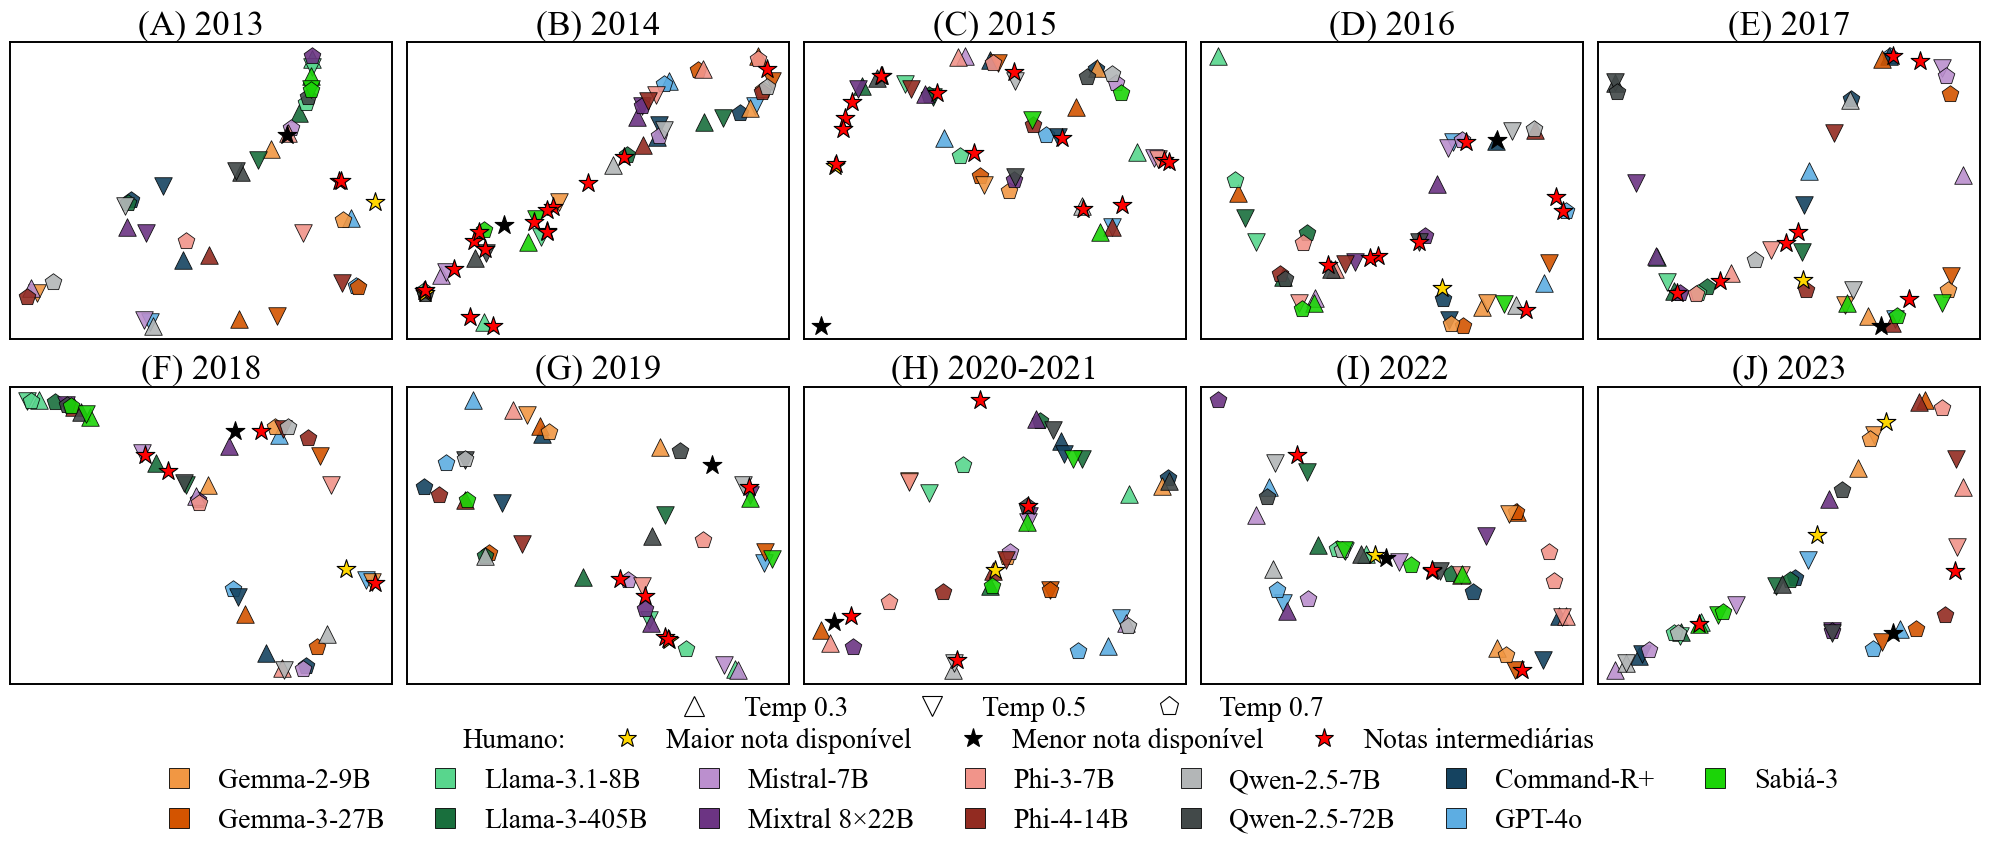

In [20]:
# ------------------------------------------------------------
# 0) Configurações
# ------------------------------------------------------------
HUMAN_JSON = "candidates_metrics_notes.json"   # ajuste aqui
AUTO_JSON  = "llms_metrics.json"         # ajuste aqui
OUTDIR     = "./tsne_figs"
PERPLEXITY = 30

# ------------------------------------------------------------
# 1) Imports e fonte global
# ------------------------------------------------------------
import json, re, math, numpy as np, pandas as pd
import matplotlib.pyplot as plt; import seaborn as sns
from math import ceil
from pathlib import Path
from sklearn.manifold import TSNE
from matplotlib.lines import Line2D
plt.rcParams["font.family"] = "Times New Roman"

# ★ cores das estrelas (humanos)
STAR_MAX = "#FFD700"   # amarelo-ouro
STAR_MIN = "#000000"   # preto
STAR_MID = "#FF0000"   # vermelho


def star_color(grade: float, gmin: float, gmax: float) -> str:
    """Cor da estrela conforme nota e extremos do ano."""
    if grade == gmax:
        return STAR_MAX
    if grade == gmin:
        return STAR_MIN
    return STAR_MID

# ------------------------------------------------------------
# 2) Regex de modelos
# ------------------------------------------------------------
MODELO_REGEXES = {
    r"command[-_]?r[-_]?plus": "Command-R+",
    r"gemma[-_]?27b":          "Gemma-3-27B",
    r"gemma[-_]?2[-_.]?9b":    "Gemma-2-9B",
    r"gemma[-_]?9b":           "Gemma-2-9B",
    r"llama.*405":             "Llama-3-405B",
    r"llama[-_.]?3\.?1.*8":    "Llama-3.1-8B",
    r"llama[-_]?8b":           "Llama-3.1-8B",
    r"mixtral.*22b":           "Mixtral 8×22B",
    r"mistral.*7b":            "Mistral-7B",
    r"mixtral[-_]?8x?7b":      "Mistral-7B",
    r"phi[-_.]?3.*":           "Phi-3-7B",
    r"phi[-_.]?4":             "Phi-4-14B",
    r"qwen.*72":               "Qwen-2.5-72B",
    r"qwen.*7b":               "Qwen-2.5-7B",
    r"sabia3":                 "Sabiá-3",
    r"gpt4o":                  "GPT-4o",
}
TEMP_RE   = re.compile(r"temp[_\-]?(\d{1,2})", re.I)
YEAR_HEAD = re.compile(r"\d{4}")

unknown_models = set()

# ------------------------------------------------------------
# 3) Funções auxiliares
# ------------------------------------------------------------
def detect_model(label: str) -> str:
    for pat, name in MODELO_REGEXES.items():
        if re.search(pat, label, re.I):
            return name
    unknown_models.add(label)
    return "Unknown-Model"

def extract_temp(label: str):
    m = TEMP_RE.search(label)
    return int(m.group(1)) if m else None

def load_json(path: str, is_human: bool) -> pd.DataFrame:
    with open(path, encoding="utf-8") as f:
        raw = json.load(f)

    return pd.DataFrame([{
        "key":      k,
        "year":     str(v["year"]),
        "is_human": is_human,
        "label":    "Human" if is_human else detect_model(k),
        "temp":     None if is_human else extract_temp(k),
        "grade":    v.get("grade"),
        **v["metrics"],
    } for k, v in raw.items()])

# ------------------------------------------------------------
# 4) Carrega e processa dados
# ------------------------------------------------------------
df = pd.concat([load_json(HUMAN_JSON, True),
                load_json(AUTO_JSON,  False)],
               ignore_index=True)

df = df[~df['key'].str.contains(r"phi\s*vision", case=False, na=False)]

if unknown_models:
    print("Unknown-Model keys:", *sorted(unknown_models), sep="\n  • ")

metric_cols = [c for c in df.columns
               if c not in ("key", "year", "is_human", "label", "temp", "grade")]
metric_cols = [c for c in metric_cols
               if not np.isclose(df[c].fillna(0), 0).all()]

X = (df[metric_cols]
      .replace({0.0: np.nan, -0.0: np.nan})
      .apply(lambda col: col.fillna(col.mean()), axis=0))

# ------------------------------------------------------------
# 5) Cores fixas e marcadores
# ------------------------------------------------------------
COLOR_MAP = {
    "Human":          STAR_MID,      # placeholder
    "GPT-4o":         "#5DADE2",
    "Sabiá-3":        "#1BD407",     # verde-escuro
    "Command-R+":     "#154360",
    "Gemma-2-9B":     "#F19743",
    "Gemma-3-27B":    "#D35400",
    "Llama-3.1-8B":   "#58D68D",
    "Llama-3-405B":   "#196F3D",
    "Mistral-7B":     "#BB8FCE",
    "Mixtral 8×22B":  "#6C3483",
    "Phi-3-7B":       "#F1948A",
    "Phi-4-14B":      "#922B21",
    "Qwen-2.5-7B":    "#B3B6B7",
    "Qwen-2.5-72B":   "#424949",
}

MARKER = {None: "s", 3: "^", 5: "v", 7: "p"}
def marker_for(temp): return MARKER.get(temp, "s")

# ------------------------------------------------------------
# 6) t-SNE por ano
# ------------------------------------------------------------
Path(OUTDIR).mkdir(exist_ok=True)
letters   = "ABCDEFGHIJKLMNOPQRSTUVWXYZ"
order_key = lambda y: int(YEAR_HEAD.search(y).group()) if YEAR_HEAD.search(y) else 9999

year_panels = []
for yr in sorted(df.year.unique(), key=order_key):
    sub = df[df.year == yr].copy()
    coords = TSNE(
        n_components=2,
        perplexity=min(PERPLEXITY, max(2, len(sub) - 1)),
        learning_rate="auto", init="random", random_state=42
    ).fit_transform(X.loc[sub.index])
    sub[["x", "y"]] = coords
    year_panels.append(sub)
    
# ------------------------------------------------------------
# 6-b) Distâncias de cada Humano para TODOS os LLMs (ordenadas)
# ------------------------------------------------------------
print("\n──────── Distâncias de cada Humano para TODOS os LLMs (ordenadas) ────────")
for yr, panel in zip(sorted(df.year.unique(), key=order_key), year_panels):
    humans = panel[panel.label == "Human"]
    llms   = panel[panel.label != "Human"]

    # notas extremas do ano
    g_min = panel.loc[panel.is_human, "grade"].min()
    g_max = panel.loc[panel.is_human, "grade"].max()

    print(f"\nAno {yr}:")
    if humans.empty or llms.empty:
        print("  (sem humanos ou sem LLMs neste ano)")
        continue

    for _, h in humans.iterrows():
        # classificação da nota
        if h.grade == g_max:
            status = "maior"
        elif h.grade == g_min:
            status = "menor"
        else:
            status = "intermediária"
        
        if status != "intermediária":

            print(f"Humano: {h['key']}  | nota = {h.grade:.2f} ({status})")

            # diferenças (dx, dy) e distâncias euclidianas
            delta = llms[['x', 'y']].values - h[['x', 'y']].values
            dists = [math.hypot(dx, dy) for dx, dy in delta]

            tmp = llms.copy()
            tmp["dist"] = dists
            tmp = tmp.sort_values("dist")

            for _, row in tmp.iterrows():
                # temp pode ser None (modelos sem variação de temperatura)
                temp_val = row['temp']
                temp_txt = f"{temp_val/10:.1f}" if pd.notna(temp_val) else "–"
                print(f"   → {row['label']:<15}  temp={temp_txt:<4}  dist = {row['dist']:.2f}")



# ------------------------------------------------------------
# 7) Painel 2 × 5
# ------------------------------------------------------------
ncols, nrows = 5, 2
fig, axes = plt.subplots(nrows, ncols,
                         figsize=(4*ncols, 4*nrows),
                         squeeze=False)

for ax in axes.flatten():
    ax.set_xticks([]); ax.set_yticks([])

for idx, (ax, panel) in enumerate(zip(axes.flatten(), year_panels)):
    g_min, g_max = (panel.loc[panel.is_human, "grade"].min(),
                    panel.loc[panel.is_human, "grade"].max())

    # LLMs
    for _, r in panel[panel.label != "Human"].iterrows():
        ax.scatter(r.x, r.y, s=160,
                   color=COLOR_MAP.get(r.label, "#000000"),
                   marker=marker_for(r.temp),
                   edgecolor="k", linewidth=0.6, alpha=0.9)

    # Humanos
    for _, r in panel[panel.label == "Human"].iterrows():
        ax.scatter(r.x, r.y, s=200,
                   color=star_color(r.grade, g_min, g_max),
                   marker="*",
                   edgecolor="k", linewidth=0.8, alpha=1.0, zorder=10)

    ax.set_title(f"({letters[idx]}) {panel.year.iloc[0]}",
                 fontsize=25, pad=6)

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor("black")
        spine.set_linewidth(1.4)

for ax in axes.flatten()[len(year_panels):]:
    ax.axis("off")

# ------------------------------------------------------------
# 8) Legendas
# ------------------------------------------------------------
# Temperaturas
temp_handles = [
    Line2D([], [], marker='^', linestyle='', markersize=14,
           markerfacecolor='none', markeredgecolor='k', markeredgewidth=0.8),
    Line2D([], [], marker='v', linestyle='', markersize=14,
           markerfacecolor='none', markeredgecolor='k', markeredgewidth=0.8),
    Line2D([], [], marker='p', linestyle='', markersize=14,
           markerfacecolor='none', markeredgecolor='k', markeredgewidth=0.8),
]
fig.legend(temp_handles, ["Temp 0.3", "Temp 0.5", "Temp 0.7"],
           frameon=False, loc="lower center",
           bbox_to_anchor=(0.5, -0.06), ncol=3, fontsize=20)

# Humanos
nota_handles = [
    Line2D([], [], linestyle='none'),                      # placeholder “Humano:”
    Line2D([], [], marker='*', linestyle='', markersize=14,
           markerfacecolor=STAR_MAX, markeredgecolor='k', markeredgewidth=0.8),
    Line2D([], [], marker='*', linestyle='', markersize=14,
           markerfacecolor=STAR_MIN, markeredgecolor='k', markeredgewidth=0.8),
    Line2D([], [], marker='*', linestyle='', markersize=14,
           markerfacecolor=STAR_MID, markeredgecolor='k', markeredgewidth=0.8),
]
nota_labels = ["Humano:",
               "Maior nota disponível",
               "Menor nota disponível",
               "Notas intermediárias"]

fig.legend(nota_handles, nota_labels,
           frameon=False, loc="lower center",
           bbox_to_anchor=(0.5, -0.10), ncol=4, fontsize=20,
           handletextpad=0.4, columnspacing=1.2)

# Modelos (formato simples, como antes)
desired_order = [
    "Gemma-2-9B", "Gemma-3-27B",
    "Llama-3.1-8B", "Llama-3-405B",
    "Mistral-7B", "Mixtral 8×22B",
    "Phi-3-7B", "Phi-4-14B",
    "Qwen-2.5-7B", "Qwen-2.5-72B",
    "Command-R+", "GPT-4o", "Sabiá-3", 
]
model_labels = [lbl for lbl in desired_order if lbl in df.label.unique()]

model_handles = [
    Line2D([], [], marker='s', linestyle='', markersize=14,
           markerfacecolor=COLOR_MAP[lbl],
           markeredgecolor='k', markeredgewidth=0.6)
    for lbl in model_labels
]

n_cols = ceil(len(model_handles) / 2) or 1
fig.legend(model_handles, model_labels,
           frameon=False, loc="lower center",
           bbox_to_anchor=(0.5, -0.20), ncol=n_cols, fontsize=20,
           handletextpad=0.4, columnspacing=1.2)

# ------------------------------------------------------------
# 9) Layout final, mostra e salva
# ------------------------------------------------------------
plt.tight_layout(rect=[0, 0, 1, 0.88])
plt.show()

fig.savefig(Path(OUTDIR) / "tsne_all_years.png",
            dpi=600, bbox_inches="tight")
plt.close()


C:\Users\gabri\AppData\Local\Temp\ipykernel_5880\2643420573.py:93: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([load_json(HUMAN_JSON, True),


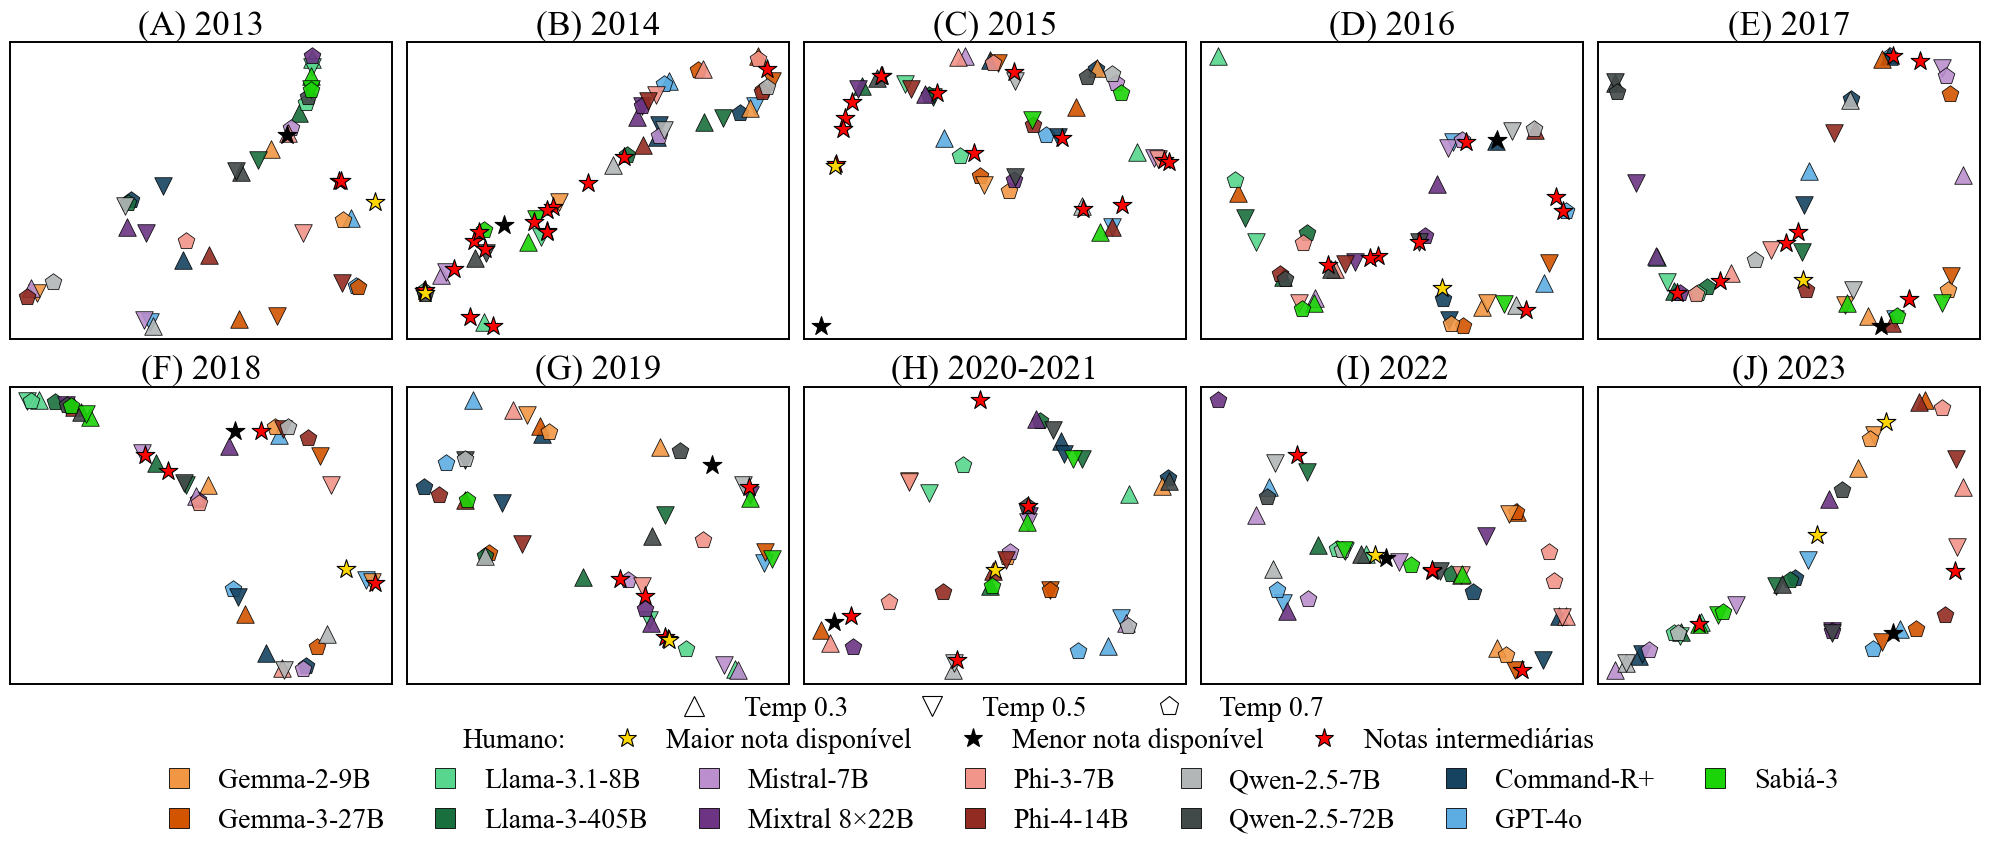

In [2]:
# ------------------------------------------------------------
# 0) Configurações
# ------------------------------------------------------------
HUMAN_JSON = "candidates_metrics_notes.json"   # ajuste aqui
AUTO_JSON  = "llms_metrics.json"               # ajuste aqui
OUTDIR     = "./tsne_figs"
PERPLEXITY = 30

# ------------------------------------------------------------
# 1) Imports e fonte global
# ------------------------------------------------------------
import json, re, math, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from math import ceil
from pathlib import Path
from sklearn.manifold import TSNE
from matplotlib.lines import Line2D
plt.rcParams["font.family"] = "Times New Roman"

# ★ cores das estrelas (humanos)
STAR_MAX = "#FFD700"   # amarelo-ouro
STAR_MIN = "#000000"   # preto
STAR_MID = "#FF0000"   # vermelho

# ★ prioridade de desenho: maior zorder = “mais na frente”
STAR_PRIORITY = {STAR_MAX: 14, STAR_MIN: 13, STAR_MID: 12}

def star_color(grade: float, gmin: float, gmax: float) -> str:
    """Cor da estrela conforme nota e extremos do ano."""
    if grade == gmax:
        return STAR_MAX
    if grade == gmin:
        return STAR_MIN
    return STAR_MID

# ------------------------------------------------------------
# 2) Regex de modelos
# ------------------------------------------------------------
MODELO_REGEXES = {
    r"command[-_]?r[-_]?plus": "Command-R+",
    r"gemma[-_]?27b":          "Gemma-3-27B",
    r"gemma[-_]?2[-_.]?9b":    "Gemma-2-9B",
    r"gemma[-_]?9b":           "Gemma-2-9B",
    r"llama.*405":             "Llama-3-405B",
    r"llama[-_.]?3\.?1.*8":    "Llama-3.1-8B",
    r"llama[-_]?8b":           "Llama-3.1-8B",
    r"mixtral.*22b":           "Mixtral 8×22B",
    r"mistral.*7b":            "Mistral-7B",
    r"mixtral[-_]?8x?7b":      "Mistral-7B",
    r"phi[-_.]?3.*":           "Phi-3-7B",
    r"phi[-_.]?4":             "Phi-4-14B",
    r"qwen.*72":               "Qwen-2.5-72B",
    r"qwen.*7b":               "Qwen-2.5-7B",
    r"sabia3":                 "Sabiá-3",
    r"gpt4o":                  "GPT-4o",
}
TEMP_RE   = re.compile(r"temp[_\-]?(\d{1,2})", re.I)
YEAR_HEAD = re.compile(r"\d{4}")

unknown_models = set()

# ------------------------------------------------------------
# 3) Funções auxiliares
# ------------------------------------------------------------
def detect_model(label: str) -> str:
    for pat, name in MODELO_REGEXES.items():
        if re.search(pat, label, re.I):
            return name
    unknown_models.add(label)
    return "Unknown-Model"

def extract_temp(label: str):
    m = TEMP_RE.search(label)
    return int(m.group(1)) if m else None

def load_json(path: str, is_human: bool) -> pd.DataFrame:
    with open(path, encoding="utf-8") as f:
        raw = json.load(f)

    return pd.DataFrame([{
        "key":      k,
        "year":     str(v["year"]),
        "is_human": is_human,
        "label":    "Human" if is_human else detect_model(k),
        "temp":     None if is_human else extract_temp(k),
        "grade":    v.get("grade"),
        **v["metrics"],
    } for k, v in raw.items()])

# ------------------------------------------------------------
# 4) Carrega e processa dados
# ------------------------------------------------------------
df = pd.concat([load_json(HUMAN_JSON, True),
                load_json(AUTO_JSON,  False)],
               ignore_index=True)

df = df[~df['key'].str.contains(r"phi\s*vision", case=False, na=False)]

if unknown_models:
    print("Unknown-Model keys:", *sorted(unknown_models), sep="\n  • ")

metric_cols = [c for c in df.columns
               if c not in ("key", "year", "is_human", "label", "temp", "grade")]
metric_cols = [c for c in metric_cols
               if not np.isclose(df[c].fillna(0), 0).all()]

X = (df[metric_cols]
      .replace({0.0: np.nan, -0.0: np.nan})
      .apply(lambda col: col.fillna(col.mean()), axis=0))

# ------------------------------------------------------------
# 5) Cores fixas e marcadores
# ------------------------------------------------------------
COLOR_MAP = {
    "Human":          STAR_MID,      # placeholder
    "GPT-4o":         "#5DADE2",
    "Sabiá-3":        "#1BD407",
    "Command-R+":     "#154360",
    "Gemma-2-9B":     "#F19743",
    "Gemma-3-27B":    "#D35400",
    "Llama-3.1-8B":   "#58D68D",
    "Llama-3-405B":   "#196F3D",
    "Mistral-7B":     "#BB8FCE",
    "Mixtral 8×22B":  "#6C3483",
    "Phi-3-7B":       "#F1948A",
    "Phi-4-14B":      "#922B21",
    "Qwen-2.5-7B":    "#B3B6B7",
    "Qwen-2.5-72B":   "#424949",
}

MARKER = {None: "s", 3: "^", 5: "v", 7: "p"}
def marker_for(temp): return MARKER.get(temp, "s")

# ------------------------------------------------------------
# 6) t-SNE por ano
# ------------------------------------------------------------
Path(OUTDIR).mkdir(exist_ok=True)
letters   = "ABCDEFGHIJKLMNOPQRSTUVWXYZ"
order_key = lambda y: int(YEAR_HEAD.search(y).group()) if YEAR_HEAD.search(y) else 9999

year_panels = []
for yr in sorted(df.year.unique(), key=order_key):
    sub = df[df.year == yr].copy()
    coords = TSNE(
        n_components=2,
        perplexity=min(PERPLEXITY, max(2, len(sub) - 1)),
        learning_rate="auto", init="random", random_state=42
    ).fit_transform(X.loc[sub.index])
    sub[["x", "y"]] = coords
    year_panels.append(sub)

# ------------------------------------------------------------
# 7) Painel 2 × 5
# ------------------------------------------------------------
ncols, nrows = 5, 2
fig, axes = plt.subplots(nrows, ncols,
                         figsize=(4*ncols, 4*nrows),
                         squeeze=False)

for ax in axes.flatten():
    ax.set_xticks([]); ax.set_yticks([])

for idx, (ax, panel) in enumerate(zip(axes.flatten(), year_panels)):
    g_min, g_max = (
        panel.loc[panel.is_human, "grade"].min(),
        panel.loc[panel.is_human, "grade"].max(),
    )

    # -------- LLMs --------
    for _, r in panel[panel.label != "Human"].iterrows():
        ax.scatter(
            r.x, r.y, s=160,
            color=COLOR_MAP.get(r.label, "#000000"),
            marker=marker_for(r.temp),
            edgecolor="k", linewidth=0.6, alpha=0.9,
            zorder=10,                 # sempre abaixo das estrelas
        )

    # -------- Humanos (estrelas) --------
    for _, r in panel[panel.label == "Human"].iterrows():
        color = star_color(r.grade, g_min, g_max)
        ax.scatter(
            r.x, r.y, s=200,
            color=color,
            marker="*",
            edgecolor="k", linewidth=0.8,
            alpha=1.0,
            zorder=STAR_PRIORITY[color],  # prioridade interna
        )

    ax.set_title(f"({letters[idx]}) {panel.year.iloc[0]}", fontsize=25, pad=6)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor("black")
        spine.set_linewidth(1.4)

for ax in axes.flatten()[len(year_panels):]:
    ax.axis("off")

# ------------------------------------------------------------
# 8) Legendas
# ------------------------------------------------------------
# Temperaturas
temp_handles = [
    Line2D([], [], marker='^', linestyle='', markersize=14,
           markerfacecolor='none', markeredgecolor='k', markeredgewidth=0.8),
    Line2D([], [], marker='v', linestyle='', markersize=14,
           markerfacecolor='none', markeredgecolor='k', markeredgewidth=0.8),
    Line2D([], [], marker='p', linestyle='', markersize=14,
           markerfacecolor='none', markeredgecolor='k', markeredgewidth=0.8),
]
fig.legend(temp_handles, ["Temp 0.3", "Temp 0.5", "Temp 0.7"],
           frameon=False, loc="lower center",
           bbox_to_anchor=(0.5, -0.06), ncol=3, fontsize=20)

# Humanos
nota_handles = [
    Line2D([], [], linestyle='none'),                      # placeholder “Humano:”
    Line2D([], [], marker='*', linestyle='', markersize=14,
           markerfacecolor=STAR_MAX, markeredgecolor='k', markeredgewidth=0.8),
    Line2D([], [], marker='*', linestyle='', markersize=14,
           markerfacecolor=STAR_MIN, markeredgecolor='k', markeredgewidth=0.8),
    Line2D([], [], marker='*', linestyle='', markersize=14,
           markerfacecolor=STAR_MID, markeredgecolor='k', markeredgewidth=0.8),
]
nota_labels = ["Humano:",
               "Maior nota disponível",
               "Menor nota disponível",
               "Notas intermediárias"]

fig.legend(nota_handles, nota_labels,
           frameon=False, loc="lower center",
           bbox_to_anchor=(0.5, -0.10), ncol=4, fontsize=20,
           handletextpad=0.4, columnspacing=1.2)

# Modelos
desired_order = [
    "Gemma-2-9B", "Gemma-3-27B",
    "Llama-3.1-8B", "Llama-3-405B",
    "Mistral-7B", "Mixtral 8×22B",
    "Phi-3-7B", "Phi-4-14B",
    "Qwen-2.5-7B", "Qwen-2.5-72B",
    "Command-R+", "GPT-4o", "Sabiá-3",
]
model_labels = [lbl for lbl in desired_order if lbl in df.label.unique()]

model_handles = [
    Line2D([], [], marker='s', linestyle='', markersize=14,
           markerfacecolor=COLOR_MAP[lbl],
           markeredgecolor='k', markeredgewidth=0.6)
    for lbl in model_labels
]
n_cols = ceil(len(model_handles) / 2) or 1
fig.legend(model_handles, model_labels,
           frameon=False, loc="lower center",
           bbox_to_anchor=(0.5, -0.20), ncol=n_cols, fontsize=20,
           handletextpad=0.4, columnspacing=1.2)

# ------------------------------------------------------------
# 9) Layout final, mostra e salva
# ------------------------------------------------------------
plt.tight_layout(rect=[0, 0, 1, 0.88])
plt.show()

fig.savefig(Path(OUTDIR) / "tsne_all_years.png",
            dpi=600, bbox_inches="tight")
plt.close()
